# AI Exam

An advanced aquatic drone, is deployed to collect critical data on marine biodiversity in a coastal region. The drone starts at point $S$, located near the shore, and must navigate to point $G$, a designated marine research site rich in coral reefs and sea life. Along the way, the drone must carefully maneuver through dynamic underwater environments, avoiding hazards and optimizing its energy usage.

The environment includes:  
1. **(O) Open Water:** Normal movement; no additional challenges.  
2. **(C) Currents:** Areas where the drone's movement is influenced by ocean currents, potentially pushing it off course.  
3. **(F) Seaweed Forests:** Dense vegetation that slows down the drone, incurring extra energy costs per move.    
5. **(E) Energy Stations:** Specific points where the drone can recharge its battery, reducing the total cost navigation.  


<img src="images/env_ex2.png" style="zoom: 20%;"/>



### Environment Details:

- **Grid Representation:** The environment is represented as in the above image (a grid 10x10).  
- $S$ - Start state: The drone's starting point at (0, 0).  
- $G$ - Goal state: The marine research site at (9, 7), providing a large positive reward +20.0 and ending the episode.  
- **Movement Costs:** Each move has a default energy cost of -0.04.  
- **Hazards:**  
  - **Strong Currents:** Entering a zone with current results in a stochastic movement:  
    - 80% chance to move as intended.  
    - 10% chance to be pushed one cell in the left direction perpendicular to the desired movement.  
    - 10% chance to be pushed one cell in the right direction perpendicular to the desired movement. 
  - **Seaweed Forests:** Entering these zones incurs an additional -0.2 reward penalty with respect to the standard movement cost (i.e., a total -0.24 penalty).

- **Energy Stations:** Provide a +1.0 reward when visited (however reaching these cells may require the agent to move far from the goal).  

You can use the following code to explore better the environment

In [11]:
import os, sys 
import tqdm

module_path = os.path.abspath(os.path.join('tools'))
if module_path not in sys.path:
    sys.path.append(module_path)

import gym, envs
from utils.ai_lab_functions import *
import numpy as np
from timeit import default_timer as timer
from tqdm import tqdm as tqdm

env_name = 'AquaticEnv-v0'
env = gym.make(env_name)

env.render()

print("\nActions encoding: ", env.actions)

# Remember that you can know the type of a cell whenever you need by accessing the grid element of the environment:
print("Cell type of start state: ",env.grid[env.startstate])
print("Cell type of goal state: ",env.grid[env.goalstate])
state = 3 # forest
print(f"Cell type of cell {env.state_to_pos(state)}: ",env.grid[state])
state = 12 # corrent
print(f"Cell type of cell {env.state_to_pos(state)}: ",env.grid[state])
state = 17 # energy station
print(f"Cell type of cell {env.state_to_pos(state)}: ",env.grid[state])

[['O' 'O' 'O' 'F' 'F' 'F' 'F' 'O' 'O' 'O']
 ['S' 'F' 'C' 'C' 'C' 'O' 'F' 'E' 'F' 'O']
 ['O' 'O' 'F' 'F' 'F' 'O' 'F' 'F' 'F' 'C']
 ['F' 'C' 'F' 'F' 'E' 'C' 'F' 'O' 'F' 'C']
 ['F' 'C' 'F' 'F' 'F' 'C' 'F' 'O' 'F' 'C']
 ['F' 'E' 'F' 'O' 'O' 'O' 'F' 'E' 'F' 'C']
 ['O' 'O' 'O' 'O' 'O' 'O' 'F' 'F' 'F' 'C']
 ['O' 'F' 'F' 'F' 'O' 'O' 'O' 'F' 'F' 'C']
 ['O' 'O' 'O' 'O' 'F' 'F' 'F' 'F' 'F' 'C']
 ['F' 'F' 'F' 'O' 'O' 'O' 'O' 'G' 'O' 'F']]

Actions encoding:  {0: 'L', 1: 'R', 2: 'U', 3: 'D'}
Cell type of start state:  S
Cell type of goal state:  G
Cell type of cell (0, 3):  F
Cell type of cell (1, 2):  C
Cell type of cell (1, 7):  E


In [12]:
#Action encoding
print("\nActions encoding: ", env.actions)

# Remember that you can know the type of a cell whenever you need by accessing the grid element of the environment:
print("Cell type of start state: ",env.grid[env.startstate])
print("Cell type of goal state: {} Reward: {}".format(env.grid[env.goalstate],env.RS[env.goalstate]))

state = 1 # normal state
print(f"\nCell type of cell {env.state_to_pos(state)}: ",env.grid[state])
print(f"Probability of effectivelty performing action {env.actions[0]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[0], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[1]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[1], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[2]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[2], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[3]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[3], state+1]}")

state = 13 # state with stochastic transitions
print(f"\nCell type of cell {env.state_to_pos(state)}: ",env.grid[state])
print(f"Probability of effectivelty performing action {env.actions[0]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[0], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[1]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[1], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[2]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[2], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[3]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[3], state+1]}")



Actions encoding:  {0: 'L', 1: 'R', 2: 'U', 3: 'D'}
Cell type of start state:  S
Cell type of goal state: G Reward: 20.0

Cell type of cell (0, 1):  O
Probability of effectivelty performing action L from cell (0, 1) to cell (0, 2): 0.0
Probability of effectivelty performing action R from cell (0, 1) to cell (0, 2): 1.0
Probability of effectivelty performing action U from cell (0, 1) to cell (0, 2): 0.0
Probability of effectivelty performing action D from cell (0, 1) to cell (0, 2): 0.0

Cell type of cell (1, 3):  C
Probability of effectivelty performing action L from cell (1, 3) to cell (1, 4): 0.0
Probability of effectivelty performing action R from cell (1, 3) to cell (1, 4): 0.8
Probability of effectivelty performing action U from cell (1, 3) to cell (1, 4): 0.1
Probability of effectivelty performing action D from cell (1, 3) to cell (1, 4): 0.1


#### Q1. Find an optimal solution to this problem by using the approach that you think is most appropriate. Motivate your choice

In [13]:
def value_iteration(environment, maxiters=300, discount=0.9, max_error=1e-3):
    """
    Performs the value iteration algorithm for a specific environment
    
    Args:
        environment: OpenAI Gym environment
        maxiters: timeout for the iterations
        discount: gamma value, the discount factor for the Bellman equation
        max_error: the maximum error allowd in the utility of any state
        
    Returns:
        policy: 1-d dimensional array of action identifiers where index i corresponds to state id i
    """
    iterations = 0
    U_1 = [0 for _ in range(environment.observation_space.n)] # vector of utilities for states S
    
    while True:
        iterations += 1
        
        delta = 0 # maximum change in the utility of any state in an iteration
        U = U_1.copy()
        for s in range(environment.observation_space.n):

            #calcolo dei valori-Q per ogni possibile azione a partire dallo stato s
            qvalues = [0 for _ in range(environment.action_space.n)]
            
            if env.grid[s] == "G":
                U_1[s] = environment.RS[s]
                continue
            
            for a in range(environment.action_space.n):
                for s_1 in range(environment.observation_space.n):
                    qvalues[a] += environment.T[s, a, s_1] * U[s_1]
                    
            U_1[s] = environment.RS[s] + discount * max(qvalues)

            if abs(U_1[s] - U[s]) > delta:
                delta = abs(U_1[s] - U[s])

        if(delta < (max_error*(1 - discount)/discount)):
            break
        
        if(iterations >= maxiters):
            break
            
    return values_to_policy(np.asarray(U), env) # automatically convert the value matrix U to a policy

In [14]:
env_name = 'AquaticEnv-v0'
env = gym.make(env_name)

solution = value_iteration(env)

You can visualize and check your solution using the following code:

Method: Value Iteration
[['D' 'D' 'D' 'D' 'R' 'D' 'R' 'D' 'L' 'L']
 ['D' 'D' 'R' 'R' 'R' 'R' 'R' 'D' 'L' 'L']
 ['R' 'D' 'R' 'R' 'D' 'R' 'R' 'D' 'L' 'L']
 ['D' 'D' 'R' 'R' 'D' 'R' 'R' 'D' 'L' 'L']
 ['D' 'D' 'R' 'D' 'D' 'D' 'R' 'D' 'L' 'L']
 ['R' 'R' 'R' 'R' 'R' 'R' 'R' 'D' 'L' 'L']
 ['D' 'R' 'R' 'R' 'R' 'D' 'D' 'D' 'D' 'D']
 ['D' 'D' 'D' 'D' 'R' 'R' 'D' 'D' 'D' 'D']
 ['R' 'R' 'R' 'D' 'D' 'D' 'D' 'D' 'D' 'D']
 ['R' 'R' 'R' 'R' 'R' 'R' 'R' 'L' 'L' 'L']]


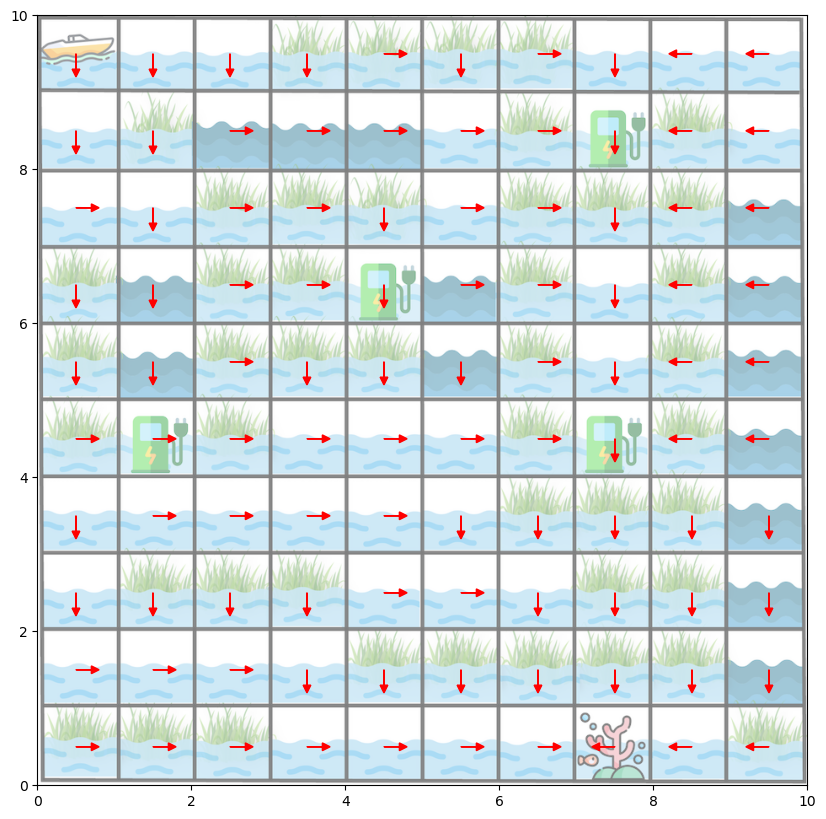

In [15]:
print("Method: Value Iteration")
visual_solution = np.vectorize(env.actions.get)(solution.reshape(env.rows, env.cols)) 

print(visual_solution)
plot_policy(policy=visual_solution, name_env="ex2_render")

#### Analyze the solution returned by your approach and comment on whether the solution passes by at least two charging stations to reach the coral for every possible execution.

L'approccio adottato tramite **Value Iteration**, con questi parametri, fa si che l'agente trovi la policy ottimale $\pi$ che massimizzi la funzione di utilità attesa.
La policy restituita, passando per stati con azioni *stocastiche* **C** (*Current*), non garantisce che l'agente passi su <u>due</u> stazioni di ricarica differenti per ogni esecuzione.